In [1]:
import json
from collections import defaultdict
from copy import deepcopy
from importlib import reload
import os
import sys

import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import pygame as pg
import seaborn as sns
import scipy.stats as sps

sys.path.append("/Users/tony/repos/physics_events/stimuli")
# sys.path.append("/Users/tony/repos/physics_events/models")
# import view_stimuli
# import record
# import baseline_models
import pyGameWorld as pgw
import pyGameWorld.viewer

# import pyGameWorld.viewer as viewer
from pyGameWorld.simulation_divergences import mae

sns.set_palette("tab10")
sns.set_theme(
    style="white",
    rc={"axes.spines.right": False, "axes.spines.top": False, "figure.figsize": (11, 9)},
)
data = pd.read_csv("data/exp1/memory_long.csv")
worlds = list(data.world.unique())

pygame 2.5.2 (SDL 2.28.3, Python 3.8.19)
Hello from the pygame community. https://www.pygame.org/contribute.html


In [2]:
def color_object(jdict, obj_name, color, transparency):
    if color == "blue":
        c = [0, 0, 255, int(transparency * 255)]
    elif color == "red":
        c = [0, 0, 255, int(transparency * 255)]
    elif color == "black":
        c = [0, 0, 0, int(transparency * 255)]
    else:
        c = [*color, int(transparency * 255)]
    jdict["world"]["objects"][obj_name]["color"] = c


def color_objects(jdict, color, obj_dict):
    for obj, transparency in obj_dict.items():
        color_object(jdict, obj, color, transparency)


def process_repr(jdict, path_idxs, ts, update, draw_spotlight=True):
    jdict = deepcopy(jdict)
    bumpers = {k: 0.05 for k in jdict["world"]["objects"] if "bump" in k}
    for k, v in update.items():
        bumpers[k] += v
    paths = []
    for i, t in zip(path_idxs, ts):
        path = jdict["outcome"]["noisePaths"][i]
        path["path"]["FOCUS"] = path["path"]["FOCUS"][:t]
        paths.append(path["path"])
    # jdict["outcome"]["noisePaths"] = paths
    color_objects(jdict, "black", bumpers)
    world = pgw.loadFromDict(jdict["world"])
    pgw.viewer._draw_world_mpl(world, draw_start=False)
    pgw.viewer._draw_paths_mpl(world, paths, draw_start=False)

    if not draw_spotlight:
        plt.gca().autoscale_view()
        plt.axis("off")
        return

    # draw spotlight
    if len(paths) == 0:
        p = jdict["world"]["objects"]["FOCUS"]["position"]
        p_ = p + np.array([0, 1])
    else:
        p = paths[-1]["FOCUS"][-1][:2]
        p_ = paths[-1]["FOCUS"][-2][:2] if len(paths[-1]["FOCUS"]) > 1 else p + np.array([0, 1])
    p = np.array(p)
    p_ = np.array(p_)
    vert = p - p_
    vert /= np.linalg.norm(vert)
    crossbar = np.array([vert[1], -vert[0]])
    crossbar /= np.linalg.norm(crossbar)
    w, h = 30, 120
    verts = [p]
    verts.append(p + h * vert + w * crossbar)
    verts.append(p + h * vert - w * crossbar)

    plt.gca().add_patch(plt.Polygon(verts, color="gray", alpha=0.2))
    plt.gca().autoscale_view()
    plt.axis("off")


def draw_model_sims(jdict, paths, path_times, color_updates):
    fig, ax = plt.subplots(3, 3, figsize=(9, 9))
    for i, (path, path_timesteps, color_step) in enumerate(zip(paths, path_times, color_updates)):
        print(path)
        colors = {}
        for j, (idx, c) in enumerate(zip(path_timesteps, color_step)):
            for k, v in c.items():
                colors[k] = v
            plt.subplot(3, 3, i * 3 + j + 1)
            process_repr(jdict, [path], [idx], colors)
            plt.tight_layout()
    return fig, ax


def draw_model_sims_individual(jdict, paths, path_times, color_updates):
    for i, (path, path_timesteps, color_step) in enumerate(zip(paths, path_times, color_updates)):
        print(path)
        colors = {}
        for j, (idx, c) in enumerate(zip(path_timesteps, color_step)):
            fig, ax = plt.subplots(figsize=(9, 9))
            for k, v in c.items():
                colors[k] = v
            # plt.subplot(3, 3, i * 3 + j + 1)
            process_repr(jdict, [path], [idx], colors, draw_spotlight=False)
            plt.tight_layout()
            fig.savefig(f"figures/jit_model_path{i}_step{j}.svg", bbox_inches="tight")


def draw_model_repr(jdict, paths, color_updates):
    # accum = {}
    accum = defaultdict(float)
    figs = []
    for i, c in enumerate(color_updates):
        fig = plt.figure(figsize=(3, 3))
        for c_ in c:
            for k, v in c_.items():
                accum[k] += v
        process_repr(
            jdict,
            paths,
            [-1] * (i + 1),
            {k: v / (i + 1) for k, v in accum.items()},
            draw_spotlight=False,
        )
        figs.append(fig)
    return figs


In [3]:
from importlib import reload
reload(pgw.viewer)

<module 'pyGameWorld.viewer' from '/Users/tony/repos/physics_events/pyGameWorld/viewer/__init__.py'>

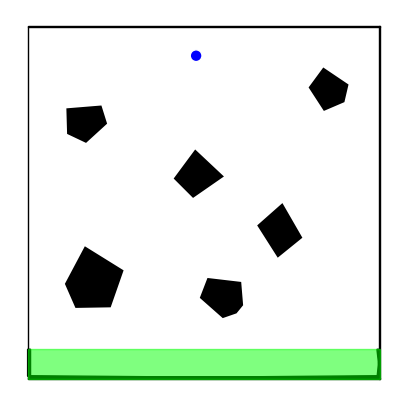

In [4]:
with open("./stimuli/figure_world.json") as f:
    demo_jdict = json.load(f)

plt.figure(figsize=(5, 5))
jdict = deepcopy(demo_jdict)
world = pgw.loadFromDict(jdict["world"])
pgw.viewer._draw_world_mpl(pgw.loadFromDict(jdict["world"]), draw_start=True, obj_colors = {"FOCUS": (0, 0, 255, 255)},
                           obj_widths={"_RightWall": 1, "_LeftWall": 1, "_TopWall": 1, "_BottomWall": 1})
plt.gca().autoscale_view()
plt.axis("equal")
plt.axis("off")
plt.savefig("figures/jit_model_world.svg", bbox_inches="tight")


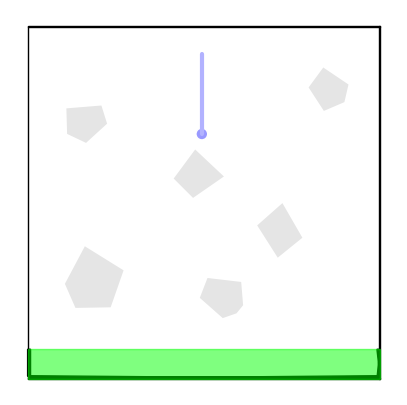

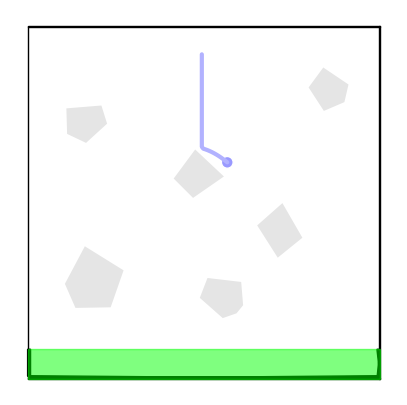

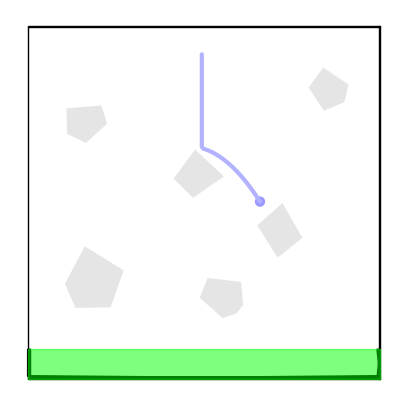

In [ ]:
path1 = 0
times1 = [40, 55, 70]
jdict = deepcopy(demo_jdict)
world = pgw.loadFromDict(jdict["world"])

for i, times in enumerate(times1):
    plt.figure(figsize=(5, 5))
    paths = jdict["outcome"]["noisePaths"][path1]["path"]
    paths = [{"FOCUS": paths["FOCUS"][:times]}]
    pgw.viewer._draw_world_mpl(world, draw_start=False, obj_colors={o: (0, 0, 0, 25.5) for o in jdict["world"]["objects"] if "bump" in o},
                               obj_widths={"_RightWall": 1, "_LeftWall": 1, "_TopWall": 1, "_BottomWall": 1})
    pgw.viewer._draw_paths_mpl(world, paths, draw_start=False, path_color = (0, 0, 255, 255))
    plt.axis("equal")
    plt.axis("off")
    plt.savefig(f"figures/jit_model_path{path1}_step{i}.svg", bbox_inches="tight")

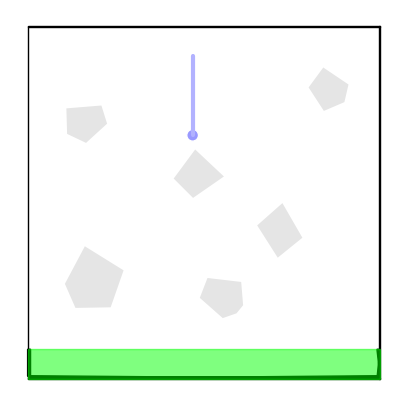

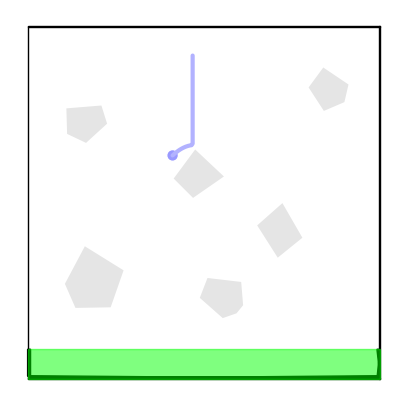

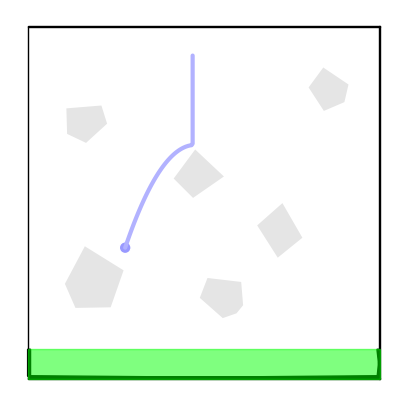

In [ ]:
path2 = 29
times2 = [40, 55, 85]
jdict = deepcopy(demo_jdict)
world = pgw.loadFromDict(jdict["world"])

for i, times in enumerate(times2):
    plt.figure(figsize=(5, 5))
    paths = jdict["outcome"]["noisePaths"][path2]["path"]
    paths = [{"FOCUS": paths["FOCUS"][:times]}]
    pgw.viewer._draw_world_mpl(world, draw_start=False, obj_colors={o: (0, 0, 0, 25.5) for o in jdict["world"]["objects"] if "bump" in o},
                               obj_widths={"_RightWall": 1, "_LeftWall": 1, "_TopWall": 1, "_BottomWall": 1})
    pgw.viewer._draw_paths_mpl(world, paths, draw_start=False, path_color=(0, 0, 255, 255))
    plt.axis("equal")
    plt.axis("off")
    plt.savefig(f"figures/jit_model_path{path2}_step{i}.svg", bbox_inches="tight")

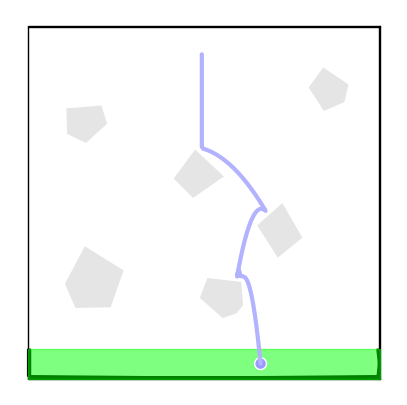

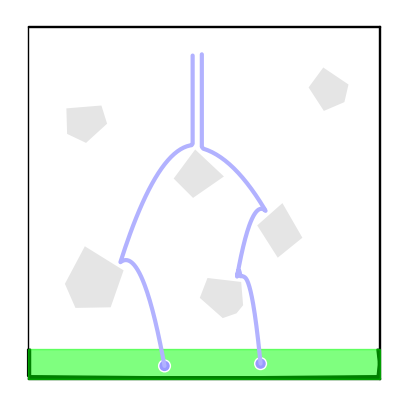

In [ ]:
jdict = deepcopy(demo_jdict)
world = pgw.loadFromDict(jdict["world"])

plt.figure(figsize=(5, 5))
paths = [jdict["outcome"]["noisePaths"][path1]["path"]]
# paths = [jdict["outcome"]["noisePaths"][path1]["path"]]
pgw.viewer._draw_world_mpl(world, draw_start=False, obj_colors={o: (0, 0, 0, 25.5) for o in jdict["world"]["objects"] if "bump" in o},
                           obj_widths={"_RightWall": 1, "_LeftWall": 1, "_TopWall": 1, "_BottomWall": 1})
pgw.viewer._draw_paths_mpl(world, paths, draw_start=False, path_color=(0, 0, 255, 255))
plt.axis("equal")
plt.axis("off")
plt.savefig("figures/jit_model_accum0.svg", bbox_inches="tight")

plt.figure(figsize=(5, 5))
paths = jdict["outcome"]["noisePaths"][path2]["path"]
paths = [jdict["outcome"]["noisePaths"][p]["path"] for p in [path1, path2]]
pgw.viewer._draw_world_mpl(world, draw_start=False, obj_colors={o: (0, 0, 0, 25.5) for o in jdict["world"]["objects"] if "bump" in o},
                           obj_widths={"_RightWall": 1, "_LeftWall": 1, "_TopWall": 1, "_BottomWall": 1})
pgw.viewer._draw_paths_mpl(world, paths, draw_start=False, path_color=(0, 0, 255, 255))
plt.axis("equal")
plt.axis("off")
plt.savefig("figures/jit_model_accum1.svg", bbox_inches="tight")

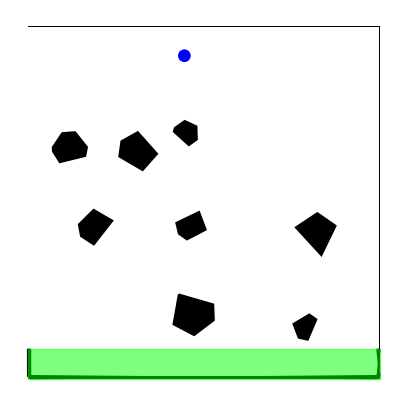

In [ ]:
demo_world = "hh_hl_unlink_plinko_0315"
with open(f"experiments/assets/exp1/targets/{demo_world}/{demo_world}.json") as f:
    demo_jdict = json.load(f)

plt.figure(figsize=(5, 5))
jdict = deepcopy(demo_jdict)
# bumpers = {k: 0.05 for k in jdict["world"]["objects"] if "bump" in k}
# bumpers["topbump_2"] = 1.0
# bumpers["topbump_1"] = 1.0
# # jdict["outcome"]["noisePaths"] = paths
# color_objects(jdict, "black", bumpers)
world = pgw.loadFromDict(jdict["world"])
pgw.viewer._draw_world_mpl(pgw.loadFromDict(jdict["world"]), draw_start=True, obj_colors = {"FOCUS": (0, 0, 255, 255)})
plt.gca().autoscale_view()
plt.axis("equal")
plt.axis("off")
plt.savefig("figures/jit_model_world.svg", bbox_inches="tight")


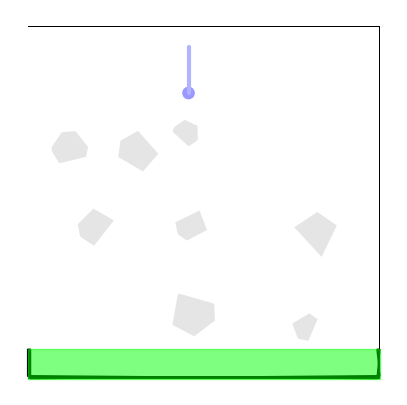

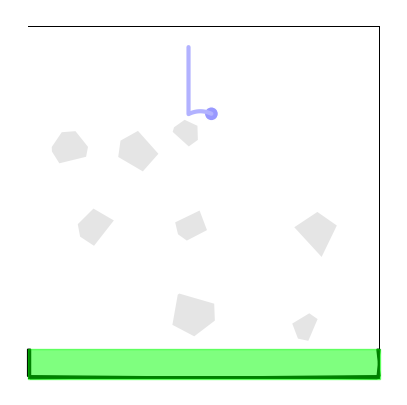

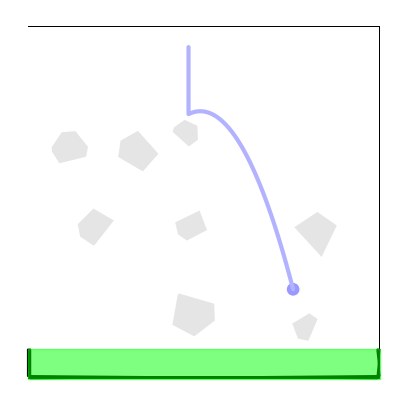

In [ ]:
path1 = 38
times1 = [30, 50, 100]
jdict = deepcopy(demo_jdict)
world = pgw.loadFromDict(jdict["world"])

for i, times in enumerate(times1):
    plt.figure(figsize=(5, 5))
    paths = jdict["outcome"]["noisePaths"][path1]["path"]
    paths = [{"FOCUS": paths["FOCUS"][:times]}]
    pgw.viewer._draw_world_mpl(world, draw_start=False, obj_colors={o: (0, 0, 0, 25.5) for o in jdict["world"]["objects"] if "bump" in o})
    pgw.viewer._draw_paths_mpl(world, paths, draw_start=False, path_color = (0, 0, 255, 255))
    plt.axis("equal")
    plt.axis("off")
    plt.savefig(f"figures/jit_model_path{path1}_step{i}.svg", bbox_inches="tight")

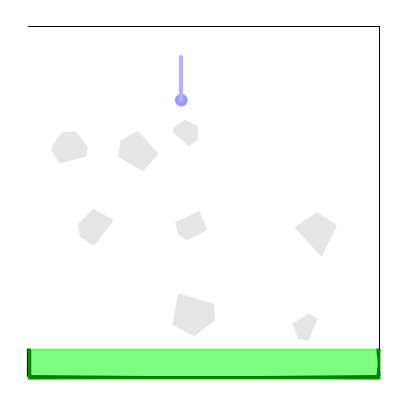

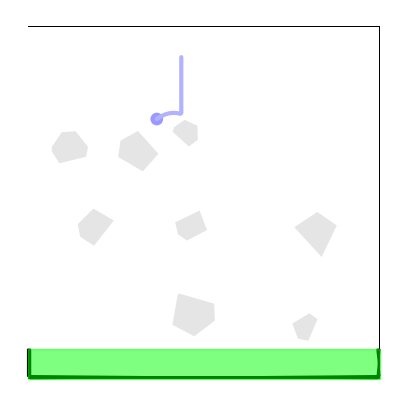

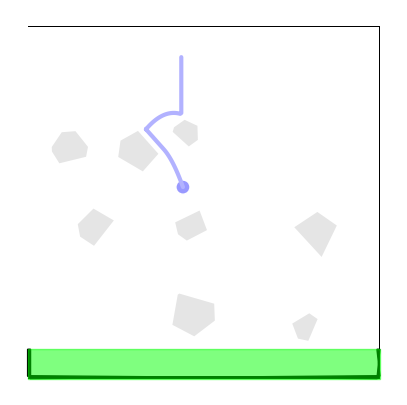

In [ ]:
path2 = 0
times2 = [30, 50, 110]
jdict = deepcopy(demo_jdict)
world = pgw.loadFromDict(jdict["world"])

for i, times in enumerate(times2):
    plt.figure(figsize=(5, 5))
    paths = jdict["outcome"]["noisePaths"][path2]["path"]
    paths = [{"FOCUS": paths["FOCUS"][:times]}]
    pgw.viewer._draw_world_mpl(world, draw_start=False, obj_colors={o: (0, 0, 0, 25.5) for o in jdict["world"]["objects"] if "bump" in o})
    pgw.viewer._draw_paths_mpl(world, paths, draw_start=False, path_color=(0, 0, 255, 255))
    plt.axis("equal")
    plt.axis("off")
    plt.savefig(f"figures/jit_model_path{path2}_step{i}.svg", bbox_inches="tight")

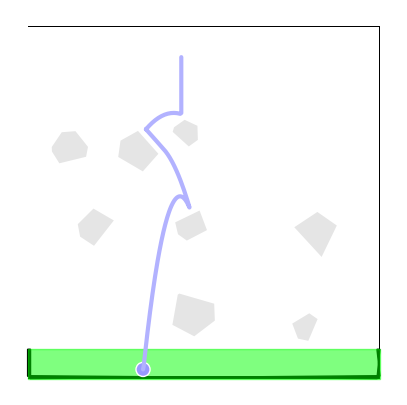

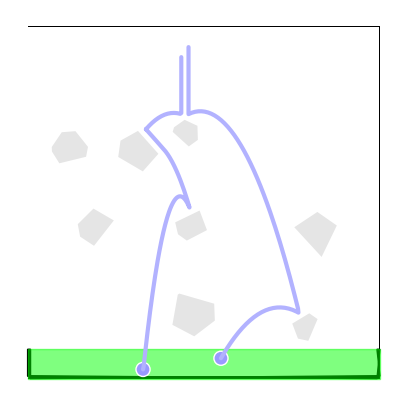

In [ ]:
jdict = deepcopy(demo_jdict)
world = pgw.loadFromDict(jdict["world"])

plt.figure(figsize=(5, 5))
paths = [jdict["outcome"]["noisePaths"][path2]["path"]]
# paths = [jdict["outcome"]["noisePaths"][path1]["path"]]
pgw.viewer._draw_world_mpl(world, draw_start=False, obj_colors={o: (0, 0, 0, 25.5) for o in jdict["world"]["objects"] if "bump" in o})
pgw.viewer._draw_paths_mpl(world, paths, draw_start=False, path_color=(0, 0, 255, 255))
plt.axis("equal")
plt.axis("off")
plt.savefig("figures/jit_model_accum0.svg", bbox_inches="tight")

plt.figure(figsize=(5, 5))
paths = jdict["outcome"]["noisePaths"][path2]["path"]
paths = [jdict["outcome"]["noisePaths"][p]["path"] for p in [path1, path2]]
pgw.viewer._draw_world_mpl(world, draw_start=False, obj_colors={o: (0, 0, 0, 25.5) for o in jdict["world"]["objects"] if "bump" in o})
pgw.viewer._draw_paths_mpl(world, paths, draw_start=False, path_color=(0, 0, 255, 255))
plt.axis("equal")
plt.axis("off")
plt.savefig("figures/jit_model_accum1.svg", bbox_inches="tight")

<class 'matplotlib.patches.Polygon'>
_LeftWall
<class 'matplotlib.patches.Polygon'>
_BottomWall
<class 'matplotlib.patches.Polygon'>
_RightWall
<class 'matplotlib.patches.Polygon'>
_TopWall
<class 'matplotlib.patches.Polygon'>
None
<class 'matplotlib.patches.Polygon'>
None
<class 'matplotlib.patches.Polygon'>
None
<class 'matplotlib.patches.Polygon'>
None
<class 'matplotlib.patches.Polygon'>
topbump_3
<class 'matplotlib.patches.Polygon'>
bottombump_1
<class 'matplotlib.patches.Polygon'>
bump_4
<class 'matplotlib.patches.Polygon'>
bump_5
<class 'matplotlib.patches.Polygon'>
bump_6
<class 'matplotlib.patches.Polygon'>
bump_7
<class 'matplotlib.patches.Circle'>
FOCUS


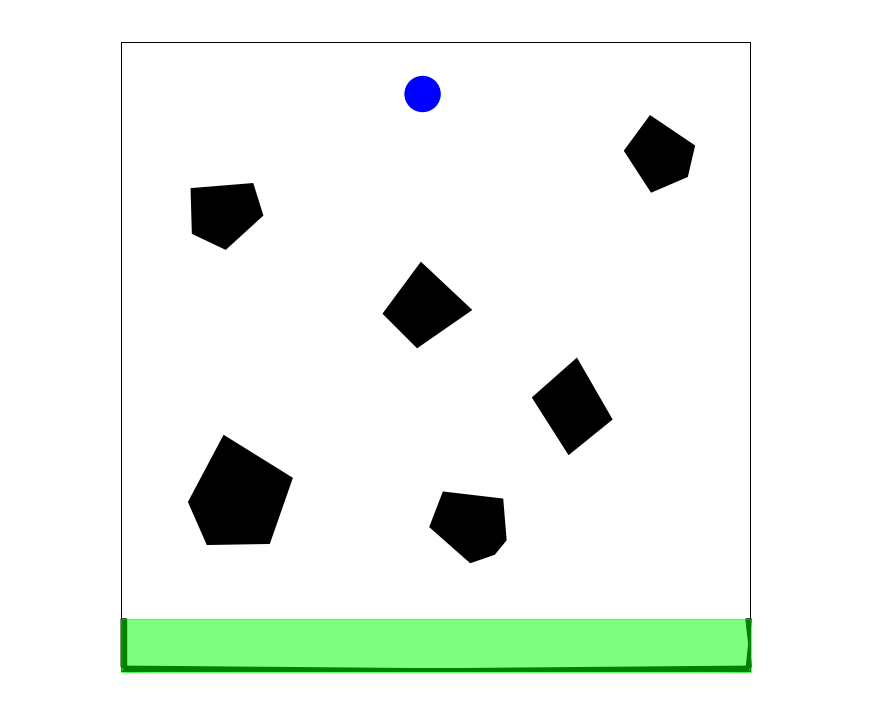

In [5]:
animation_jdict = deepcopy(demo_jdict)
animation_jdict["world"]["objects"]["FOCUS"]["radius"] = 18
pgw.viewer._draw_world_mpl(pgw.loadFromDict(animation_jdict["world"]), draw_start=True, obj_colors = {"FOCUS": (0, 0, 255, 255)})
plt.gca().autoscale_view()
plt.axis("equal")
plt.axis("off")
for p in plt.gca().patches:
    print(p.__class__)
    print(p.get_gid())

In [64]:
from matplotlib.animation import FuncAnimation
from matplotlib.path import Path
from matplotlib.patches import PathPatch


class AnimationState:
    def __init__(self, jdict, figure):
        self.jdict = jdict
        self.world = pgw.loadFromDict(jdict["world"])
        self.path_idx = 0
        self.path = jdict["outcome"]["noisePaths"][self.path_idx]["path"]
        self.collision_times = {
            40: "topbump_3",
            70: "bump_4",
            113: "bottombump_1",
        }

        self.frame = 0
        self.perception_freeze = 0
        self.arrow_freeze = 0
        self.encode_freeze = 0
        self.freeze_triggers = {}

        self.focus_artist = None
        self.path_artist = None
        self.poly_artists = {}
        self.shadow_artist = None

        self.sim_ax = None
        self.perception_ax = None
        self.figure = figure

    def draw_init(self):
        ax = self.figure.add_subplot(121)
        self.perception_ax = ax
        pgw.viewer._draw_world_mpl(self.world, draw_start=True)
        for p in ax.patches:
            if isinstance(p, plt.Circle):
                self.focus_artist = p
            if isinstance(p, plt.Polygon):
                for name, o in self.jdict["world"]["objects"].items():
                    if name == p.get_gid():
                        self.poly_artists[name + "_perception"] = p
                        break
        self.perception_ax.set_aspect("equal")
        self.perception_ax.axis("off")
        self.perception_ax.set_xlim(0, 600)
        self.perception_ax.set_ylim(0, 700)
        # self.perception_ax.autoscale_view()
        v = self.shadow_patch(
            center=self.jdict["world"]["objects"]["FOCUS"]["position"], radius=80
        )
        self.shadow_artist = ax.fill(
            v[:, 0], v[:, 1], color="gray", alpha=0.85, lw=0
        )[0]
        print(self.shadow_artist)

        ax = self.figure.add_subplot(122)
        self.sim_ax = ax
        bumper_colors = {n: (0, 0, 0, 15.5) for n in self.jdict["world"]["objects"] if "bump" in n}
        pgw.viewer._draw_world_mpl(self.world, draw_start=True, obj_colors=bumper_colors)
        for p in ax.patches:
            if isinstance(p, plt.Circle):
                self.focus_artist = p
            if isinstance(p, plt.Polygon):
                for name, o in self.jdict["world"]["objects"].items():
                    if name == p.get_gid():
                        self.poly_artists[name] = p
                        break
        print(ax.patches)
        self.path_artist = plt.Line2D(
            [], [], color="red", linewidth=10, linestyle="-", label="Path", alpha=0.5
        )
        self.sim_ax.add_line(self.path_artist)
        self.sim_ax.set_aspect("equal")
        self.sim_ax.axis("off")
        # self.sim_ax.autoscale_view()
        self.sim_ax.set_xlim(0, 600)
        self.sim_ax.set_ylim(0, 700)

        self.perception_ax.set_title("Perception", fontsize=15)
        self.sim_ax.set_title("Simulation", fontsize=15)

        return self.focus_artist, self.path_artist, *self.poly_artists.values(), self.shadow_artist

    def draw_frame(self, tick):
        assert self.focus_artist is not None, "Focus artist not found in the patches."
        assert self.path_artist is not None, "Path artist not found in the patches."
        assert self.shadow_artist is not None, "Shadow artist not found in the patches."

        updated = []
        frame = self.frame
        if frame >= len(self.path["FOCUS"]):
            return updated


        freeze_frames = self.perception_freeze + self.arrow_freeze + self.encode_freeze
        if frame in self.collision_times and freeze_frames == 0:
            self.perception_freeze = 40
            # self.arrow_freeze = 40
            self.encode_freeze = 40

            obj = self.collision_times[frame]
            self.freeze_triggers["perception"] = obj
            self.poly_artists[obj + "_perception"].set_color((1, 0, 0, 1))
            self.poly_artists[obj + "_perception"].set_zorder(2)

            # arrow = self.perception_ax.arrow(630, 300, 200, 0,
            #                                     width=0, color=(0, 0, 0, 1), zorder=-2)
            # self.freeze_triggers["arrow"] = arrow
            # print(self.freeze_triggers)

        freeze_frames = self.perception_freeze + self.arrow_freeze + self.encode_freeze
        if freeze_frames == 0:
            pos = self.path["FOCUS"][frame]
            v = self.shadow_patch(center=pos[:2], radius=50)
            self.shadow_artist.set_xy(v)
            updated.append(self.shadow_artist)
            # self.perception_ax.set_title(frame)

            updated.append(self.focus_artist)
            updated.append(self.path_artist)
            path = self.path["FOCUS"]
            if len(path) == 0:
                return

            path_until_now = [p[:2] for p in path[: frame + 1]]
            self.focus_artist.set_center(path_until_now[-1])
            self.path_artist.set_data(
                [p[0] for p in path_until_now], [p[1] for p in path_until_now]
            )

                # bump_name = self.collision_times[frame]
                # if bump_name in self.poly_artists:
                #     self.poly_artists[bump_name].set_color((0, 0, 0, 1))
                #     updated.append(self.poly_artists[bump_name])
                # self.panel2_freeze = 30

            self.frame += 1
        else:
            if self.perception_freeze > 0:
                self.perception_freeze -= 1
            elif self.arrow_freeze > 0:
                self.arrow_freeze -= 1
            elif self.encode_freeze > 0:
                self.encode_freeze -= 1

            if self.perception_freeze == 0:
                # perception freeze is over
                obj = self.freeze_triggers["perception"]
                self.poly_artists[obj + "_perception"].set_color((0, 0, 0, 1))
                self.poly_artists[obj + "_perception"].set_zorder(0)

                self.poly_artists[obj].set_color((0, 0, 0, 1))

            if self.encode_freeze == 0:
                # encode freeze is over
                self.frame += 1

        return updated

    def make_animation(self, num_frames):
        return FuncAnimation(
            self.figure,
            self.draw_frame,
            frames=num_frames,
            init_func=self.draw_init,
            repeat=False,
            interval=1000 / 45,  # 45 FPS
            # blit=True,
        )

    def shadow_patch(self, center, radius):
        rect = np.array([
            [0, 0],
            [0, 600],
            [600, 600],
            [600, 0],
            [0, 0]
        ])
        theta = np.linspace(0, 2 * np.pi, 100)
        x = center[0] + radius * np.cos(theta)
        y = center[1] + radius * np.sin(theta)
        circle_pts = np.vstack((x, y)).T[::-1]  # reverse direction
        vertices = np.concatenate([rect, circle_pts[::-1]])
        return vertices

Polygon106((0, 0) ...)
<Axes.ArtistList of 15 patches>


Polygon106((0, 0) ...)
<Axes.ArtistList of 15 patches>


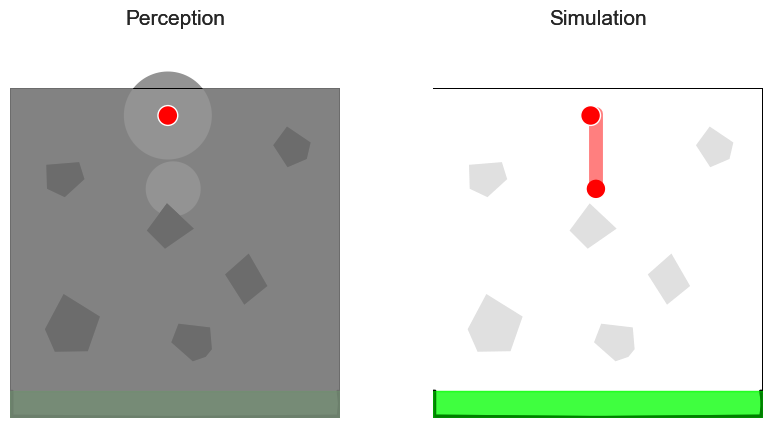

In [65]:
from IPython.display import HTML
figure = plt.figure(figsize=(10, 5))
state = AnimationState(animation_jdict, figure)
animation = state.make_animation(40)
HTML(animation.to_html5_video())
# plt.close(figure)

Polygon106((0, 0) ...)
<Axes.ArtistList of 15 patches>
Polygon106((0, 0) ...)
<Axes.ArtistList of 15 patches>


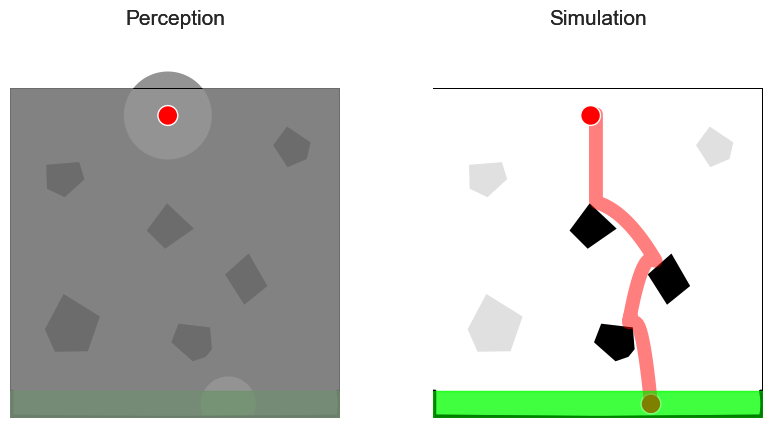

In [66]:
figure = plt.figure(figsize=(10, 5))
state = AnimationState(animation_jdict, figure)
animation = state.make_animation(480)
animation.save("figures/animation.mp4", writer="ffmpeg", fps=45)
# HTML(animation.to_html5_video())

In [ ]:
list(state.perception_ax.patches)[-1].get_xy()

array([[  0.        ,   0.        ],
       [  0.        , 600.        ],
       [600.        , 600.        ],
       [600.        ,   0.        ],
       [  0.        ,   0.        ],
       [254.8858503 , 421.04287538],
       [254.78518413, 424.21407136],
       [254.48359095, 427.37249806],
       [253.98228517, 430.5054376 ],
       [253.28328537, 433.60027474],
       [252.38940619, 436.64454766],
       [251.30424695, 439.62599816],
       [250.03217722, 442.53262098],
       [248.57831916, 445.35271218],
       [246.94852695, 448.07491625],
       [245.14936318, 450.68827183],
       [243.18807246, 453.18225586],
       [241.07255221, 455.54682595],
       [238.81132088, 457.77246081],
       [236.41348366, 459.85019859],
       [233.88869578, 461.77167298],
       [231.24712368, 463.52914687],
       [228.49940404, 465.11554355],
       [225.65660095, 466.52447514],
       [222.73016138, 467.75026839],
       [219.73186907, 468.78798745],
       [216.67379708, 469.63345379],
 

In [ ]:
state.ax

<Axes: >